# SAM3 Mode Comparison: Text vs Visual Exemplar

Compare three SAM3 inference modes on LVIS dataset:

1. **Classic (Text-Only)** — category names as CLIP text prompts, no visual reference
2. **Visual Exemplar (generic text)** — bounding boxes from reference images, text set to `"visual"` placeholder
3. **Visual Exemplar (real category name)** — bounding boxes + real category name (e.g. `"sheep"`)

Goal: see whether providing the real category name alongside visual exemplars improves detection.

In [161]:
import copy
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from instantlearn.data import LVISDataset
from instantlearn.data.lvis import LVISAnnotationMode
from instantlearn.data.base import Batch
from instantlearn.data.base.sample import Sample
from instantlearn.models.sam3 import SAM3, Sam3PromptMode
from instantlearn.visualizer import render_predictions

## Configuration

In [ ]:
DATASET_ROOT = Path("/home/rgangire/workspace/data/prompt/lvis")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PRECISION = "fp32"
CONFIDENCE_THRESHOLD = 0.3
CATEGORIES = ["avocado", "bicycle"]  # Two categories to compare
N_SHOTS = 1

# ── Sampling config ──

# Set SHUFFLE=True to randomize which reference/target images are picked.print(f"Shuffle: {SHUFFLE}, Seed: {RANDOM_SEED}, Ref index: {REF_INDEX}")

# Set SHUFFLE=False + specific indices for reproducible manual selection.print(f"Device: {DEVICE}, Precision: {PRECISION}")

SHUFFLE = False           # True: random selection, False: use indices below

RANDOM_SEED = 42         # Only used when SHUFFLE=True (set to None for different results each run)    random.seed(RANDOM_SEED)

REF_INDEX = 1            # Which reference sample to use (when SHUFFLE=False)if SHUFFLE and RANDOM_SEED is not None:

MAX_TARGETS = 3          # Number of target images per category
TARGET_INDICES = None    # Explicit target indices, e.g. [0, 5, 10]. None = first MAX_TARGETS.

## Load Dataset

LVIS in **INSTANCE** mode provides per-instance bounding boxes needed for visual exemplar.

In [163]:
dataset = LVISDataset(
    root=DATASET_ROOT,
    categories=CATEGORIES,
    n_shots=N_SHOTS,
    annotation_mode=LVISAnnotationMode.INSTANCE,
)

print(f"Categories: {dataset.categories}")
print(f"Total samples: {len(dataset)}")

Categories: ['watch', 'watermelon']
Total samples: 386


## Initialize SAM3 Model

We use a single model instance and switch `prompt_mode` between experiments.

In [164]:
model = SAM3(
    device=DEVICE,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    precision=PRECISION,
)
print("SAM3 model loaded.")

SAM3 model loaded.


## Helper Functions

In [165]:
def tensor_to_rgb(image_tensor: torch.Tensor) -> np.ndarray:
    """Convert CHW float tensor to HWC uint8 RGB numpy array."""
    img = image_tensor.cpu()
    if img.dtype.is_floating_point:
        img = img.clamp(0, 255).to(torch.uint8)
    return img.permute(1, 2, 0).numpy()


def get_reference_and_targets(
    dataset, category_name, max_targets=3,
    shuffle=False, ref_index=0, target_indices=None,
):
    """Get reference sample (with bboxes) and target samples for a category.

    Args:
        dataset: The LVIS dataset.
        category_name: Category to filter by.
        max_targets: Maximum number of target samples.
        shuffle: If True, shuffle the datasets using RANDOM_SEED before selection.
        ref_index: Index of the reference sample to pick (after optional shuffle).
        target_indices: Explicit list of target indices, or None for first max_targets.
    """
    ref_ds = dataset.get_reference_dataset(category=category_name)
    tgt_ds = dataset.get_target_dataset(category=category_name)

    # Build reference batch filtered to this category
    ref_samples = []
    for sample in ref_ds:
        filtered = sample.filter_by_category(category_name)
        if filtered is not None:
            ref_samples.append(filtered)

    if shuffle:
        rng = random.Random(RANDOM_SEED)
        rng.shuffle(ref_samples)

    # Pick the requested reference
    if ref_index < len(ref_samples):
        ref_samples = [ref_samples[ref_index]]
    elif ref_samples:
        ref_samples = [ref_samples[0]]

    # Collect target samples
    n_tgt = len(tgt_ds)
    if target_indices is not None:
        tgt_samples = [tgt_ds[i] for i in target_indices if i < n_tgt]
    elif shuffle:
        indices = list(range(n_tgt))
        rng = random.Random(RANDOM_SEED + 1)
        rng.shuffle(indices)
        tgt_samples = [tgt_ds[i] for i in indices[:max_targets]]
    else:
        tgt_samples = [tgt_ds[i] for i in range(min(max_targets, n_tgt))]

    return ref_samples, tgt_samples


def strip_annotations(samples):
    """Return image-only copies so ground truth isn't mistaken for prompts."""
    return [Sample(image=s.image, image_path=s.image_path) for s in samples]


def box_iou(boxes1, boxes2):
    """Compute IoU between two sets of boxes [N, 4] and [M, 4] in xyxy format."""
    x1 = np.maximum(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = np.maximum(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = np.minimum(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = np.minimum(boxes1[:, None, 3], boxes2[None, :, 3])
    inter = np.maximum(x2 - x1, 0) * np.maximum(y2 - y1, 0)
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    union = area1[:, None] + area2[None, :] - inter
    return inter / np.maximum(union, 1e-6)


def compute_tp_fp(pred, gt_sample, category_name, iou_threshold=0.5):
    """Count TP and FP by matching predicted boxes to GT boxes via IoU.

    Returns: (tp, fp, n_gt, mean_iou_of_matches)
    """
    pred_boxes = pred["pred_boxes"][:, :4].cpu().numpy()
    n_pred = len(pred_boxes)

    # Get GT boxes for this category
    gt_bboxes = gt_sample.bboxes
    gt_cats = gt_sample.categories
    if gt_bboxes is not None and gt_cats is not None:
        indices = [i for i, c in enumerate(gt_cats) if c == category_name]
        if indices:
            gt_boxes = np.array(gt_bboxes)[indices][:, :4]
            if isinstance(gt_boxes, torch.Tensor):
                gt_boxes = gt_boxes.cpu().numpy()
        else:
            gt_boxes = np.empty((0, 4))
    else:
        gt_boxes = np.empty((0, 4))

    n_gt = len(gt_boxes)

    if n_pred == 0:
        return 0, 0, n_gt, 0.0
    if n_gt == 0:
        return 0, n_pred, 0, 0.0

    iou_matrix = box_iou(pred_boxes, gt_boxes)
    tp = 0
    matched_ious = []
    matched_gt = set()
    # Greedy matching: highest IoU first
    for pred_idx in range(n_pred):
        best_gt = iou_matrix[pred_idx].argmax()
        if iou_matrix[pred_idx, best_gt] >= iou_threshold and best_gt not in matched_gt:
            tp += 1
            matched_gt.add(best_gt)
            matched_ious.append(iou_matrix[pred_idx, best_gt])
    fp = n_pred - tp
    mean_iou = float(np.mean(matched_ious)) if matched_ious else 0.0
    return tp, fp, n_gt, mean_iou


def show_results(target_samples, predictions_dict, category_name, color_map=None):
    """Show side-by-side results for all modes with TP/FP counts."""
    if color_map is None:
        color_map = {0: [0, 200, 0], 1: [200, 0, 0], 2: [0, 0, 200]}

    modes = list(predictions_dict.keys())
    n_targets = len(target_samples)
    n_modes = len(modes)

    fig, axes = plt.subplots(n_targets, n_modes + 1, figsize=(6 * (n_modes + 1), 6 * n_targets))
    if n_targets == 1:
        axes = axes[np.newaxis, :]

    for row, sample in enumerate(target_samples):
        img_rgb = tensor_to_rgb(sample.image)

        # Count GT for this image
        gt_cats = sample.categories or []
        n_gt = sum(1 for c in gt_cats if c == category_name)

        # Show original image with GT count
        axes[row, 0].imshow(img_rgb)
        axes[row, 0].set_title(f"Target {row + 1}\nGT: {n_gt} objects", fontsize=12)
        axes[row, 0].axis("off")

        # Show each mode's predictions
        for col, mode_name in enumerate(modes, 1):
            pred = predictions_dict[mode_name][row]
            tp, fp, _, mean_iou = compute_tp_fp(pred, sample, category_name)
            result_img = render_predictions(img_rgb.copy(), pred, color_map)
            axes[row, col].imshow(result_img)

            title = f"{mode_name}\nTP={tp}  FP={fp}  (of {n_gt} GT)"
            if mean_iou > 0:
                title += f"  IoU={mean_iou:.2f}"
            axes[row, col].set_title(title, fontsize=10)
            axes[row, col].axis("off")

    fig.suptitle(f"Category: {category_name}", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

## Run Comparison

For each category:

1. **Text-Only (Classic)**: `fit()` with category name only (no image/bbox), `predict()` uses CLIP text
2. **Visual Exemplar + `"visual"`**: `fit()` with reference image + bbox but category name replaced with `"visual"`
3. **Visual Exemplar + real name**: `fit()` with reference image + bbox + real category name (e.g. `"sheep"`)


Category: watch
  Reference: 1 bbox(es), categories=['watch']
  Targets: 3 images
  Text-Only: done
  Visual Exemplar (generic text): done
  Visual Exemplar (real name): done


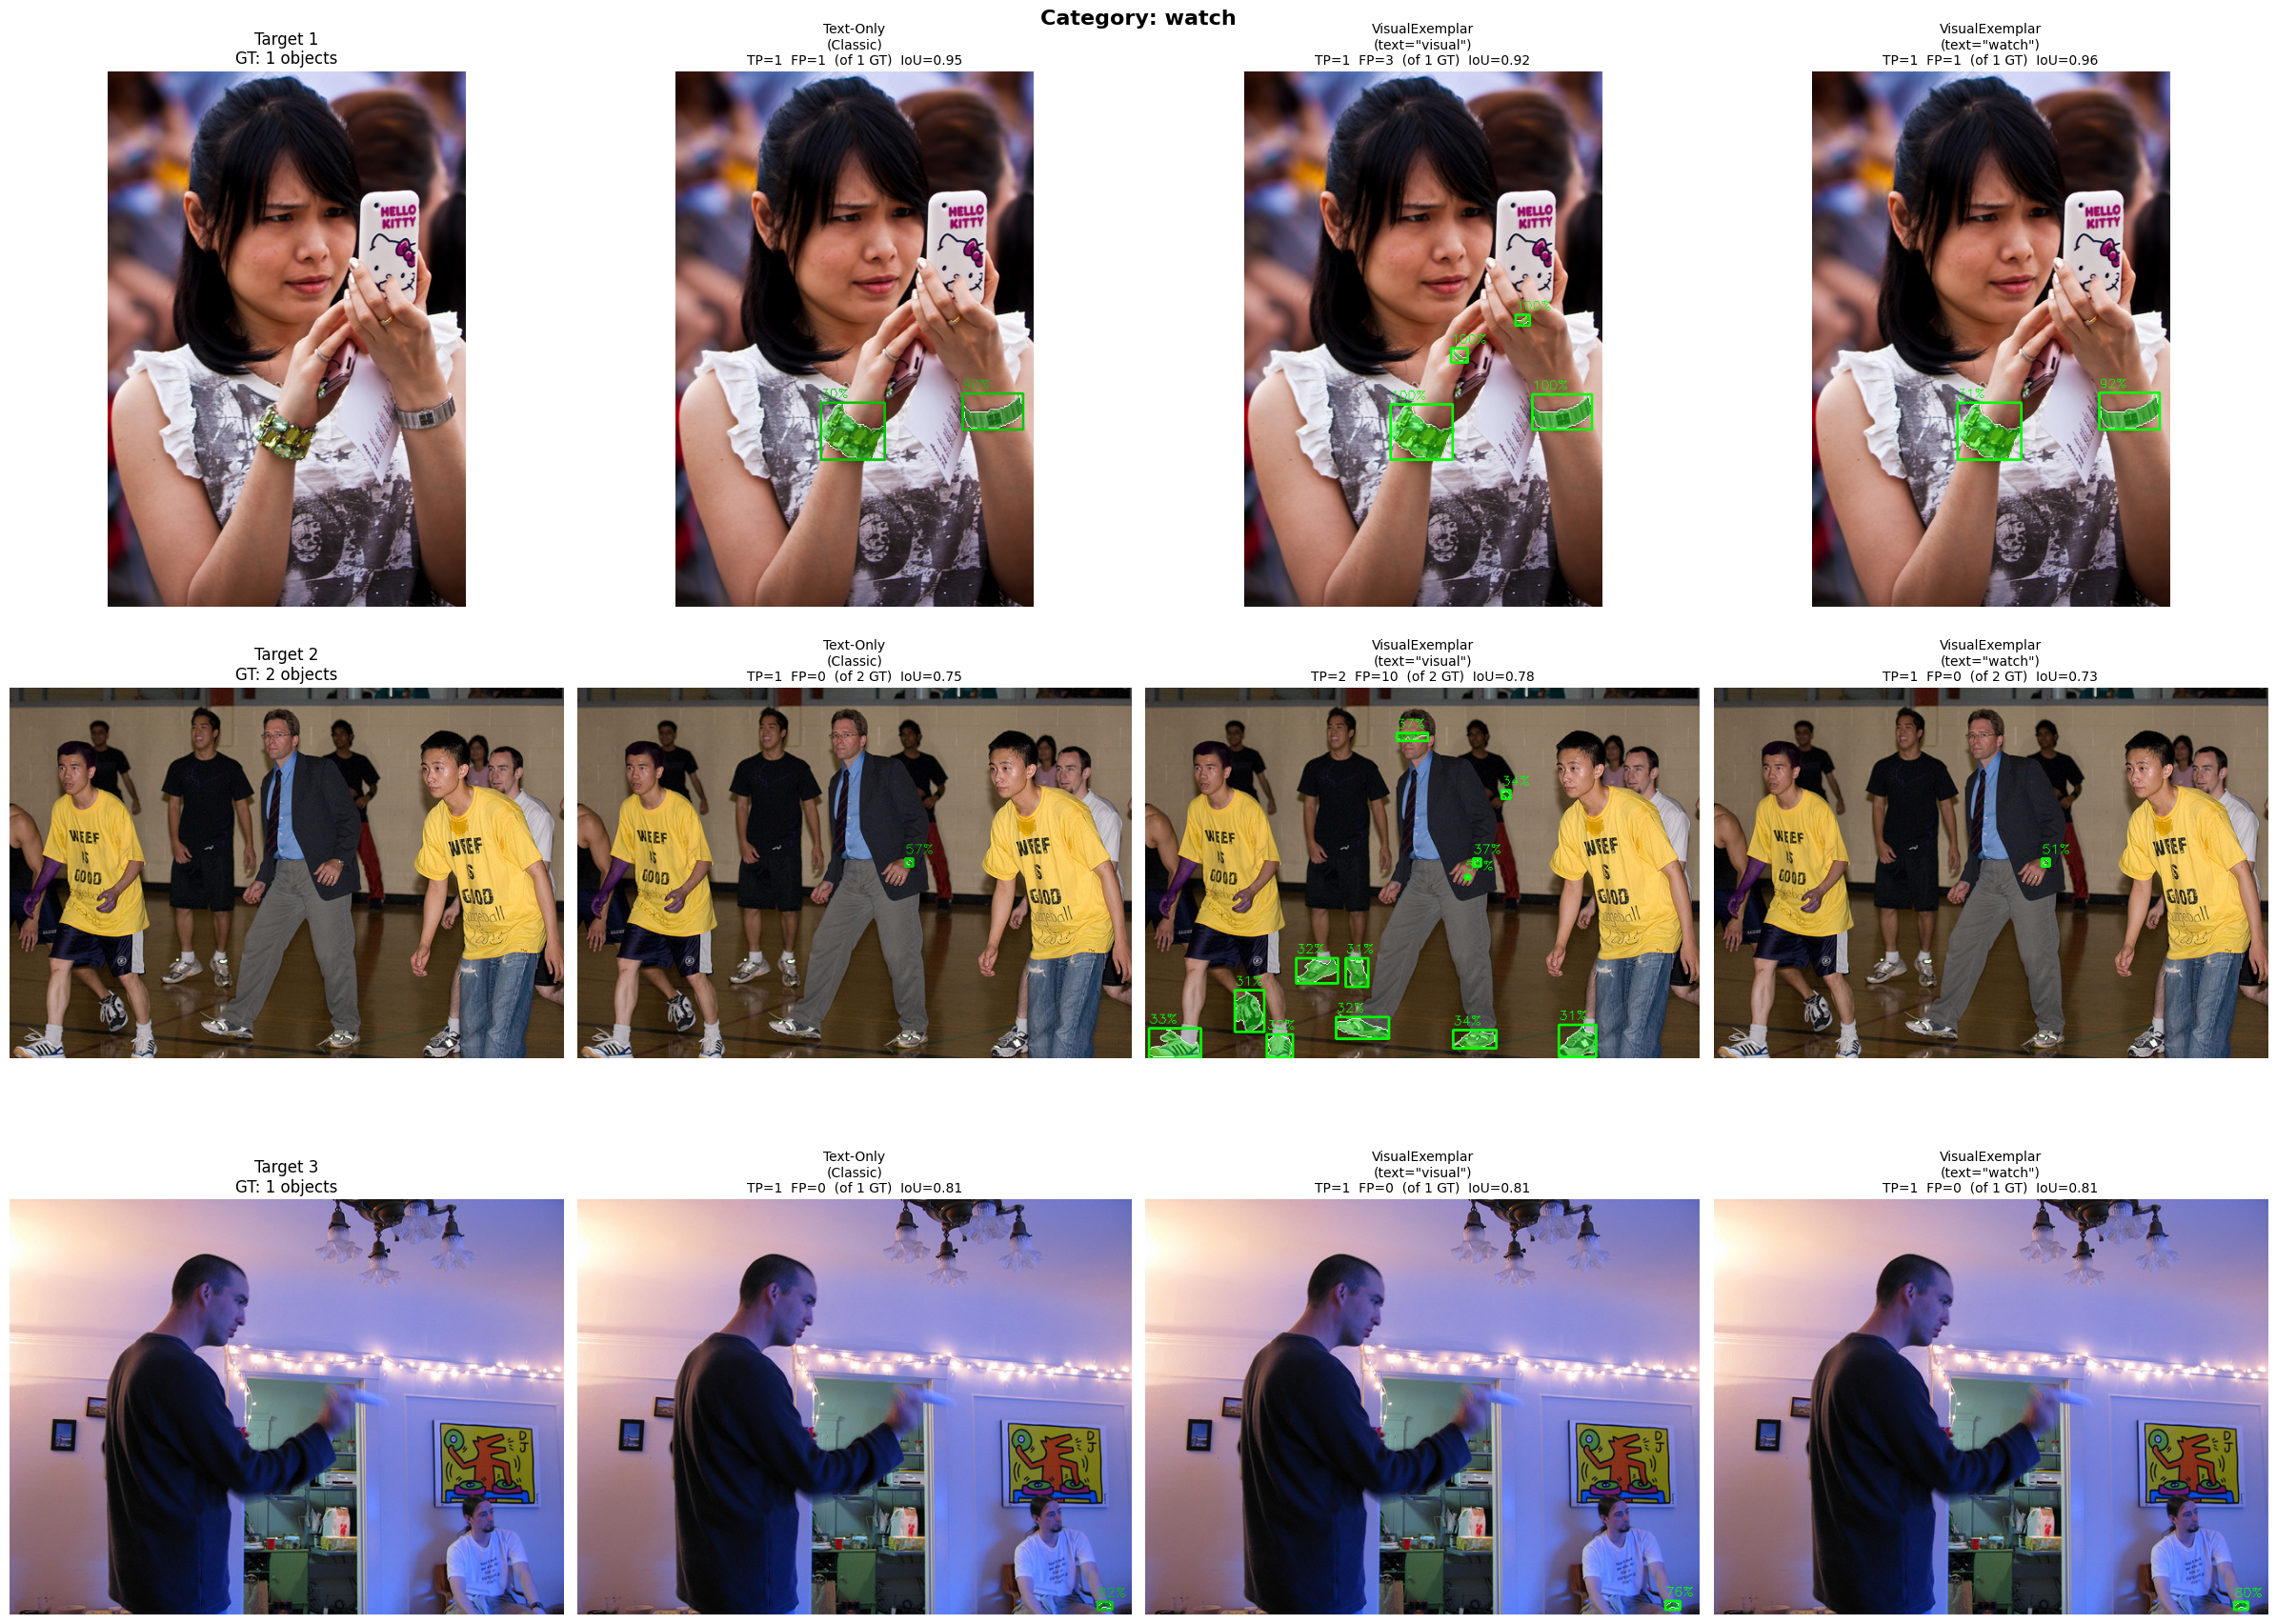


Category: watermelon
  Reference: 7 bbox(es), categories=['watermelon', 'watermelon', 'watermelon', 'watermelon', 'watermelon', 'watermelon', 'watermelon']
  Targets: 3 images
  Text-Only: done
  Visual Exemplar (generic text): done


In [ ]:
for category_name in CATEGORIES:
    print(f"\n{'=' * 60}")
    print(f"Category: {category_name}")
    print(f"{'=' * 60}")

    ref_samples, tgt_samples = get_reference_and_targets(
        dataset, category_name, max_targets=MAX_TARGETS,
        shuffle=SHUFFLE, ref_index=REF_INDEX, target_indices=TARGET_INDICES,
    )

    if not ref_samples:
        print(f"  No reference samples with bboxes for '{category_name}', skipping.")
        continue
    if not tgt_samples:
        print(f"  No target samples for '{category_name}', skipping.")
        continue

    ref_sample = ref_samples[0]
    print(f"  Reference: {len(ref_sample.bboxes)} bbox(es), categories={ref_sample.categories}")
    print(f"  Targets: {len(tgt_samples)} images")

    predictions = {}

    # Strip ground truth annotations from targets so they are image-only
    tgt_clean = strip_annotations(tgt_samples)

    # ── Mode 1: Classic Text-Only ──
    model.prompt_mode = Sam3PromptMode.CLASSIC
    text_ref = Sample(categories=[category_name], category_ids=[0])
    model.fit(text_ref)
    predictions["Text-Only\n(Classic)"] = model.predict(tgt_clean)
    print(f"  Text-Only: done")

    # ── Mode 2: Visual Exemplar + "visual" placeholder ──
    model.prompt_mode = Sam3PromptMode.VISUAL_EXEMPLAR
    ref_generic = copy.deepcopy(ref_sample)
    ref_generic.categories = ["visual"] * len(ref_generic.categories)
    model.fit(ref_generic)
    predictions["VisualExemplar\n(text=\"visual\")"] = model.predict(tgt_clean)
    print(f"  Visual Exemplar (generic text): done")

    # ── Mode 3: Visual Exemplar + real category name ──
    model.prompt_mode = Sam3PromptMode.VISUAL_EXEMPLAR
    model.fit(ref_sample)  # original sample has real category name
    predictions[f"VisualExemplar\n(text=\"{category_name}\")"] = model.predict(tgt_clean)
    print(f"  Visual Exemplar (real name): done")

    # ── Show results ──
    show_results(tgt_samples, predictions, category_name)

## Show Reference Samples

Visualize the reference image and bounding boxes used for visual exemplar modes.

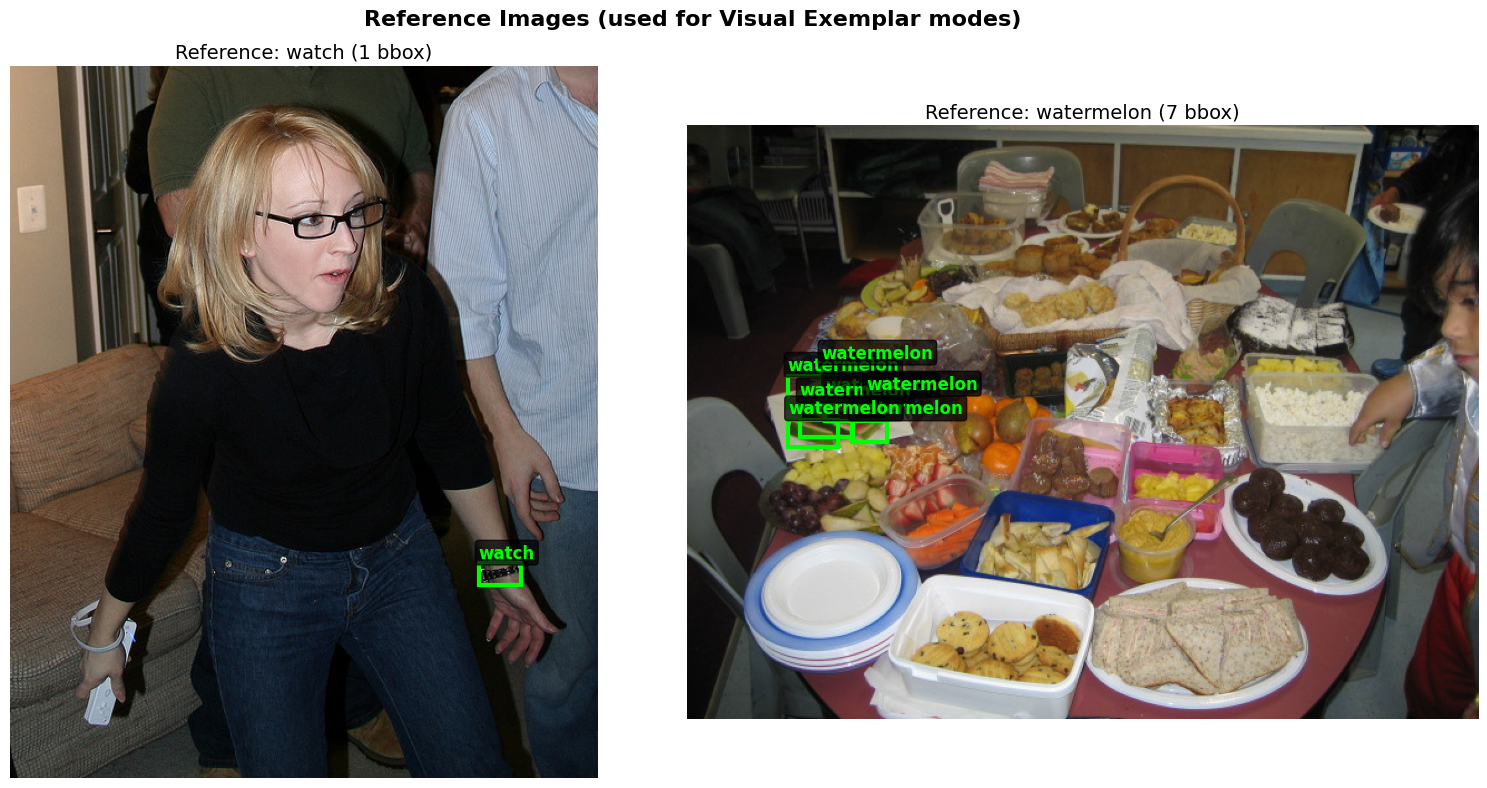

In [ ]:
fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(8 * len(CATEGORIES), 8))
if len(CATEGORIES) == 1:
    axes = [axes]

for ax, category_name in zip(axes, CATEGORIES):
    ref_samples, _ = get_reference_and_targets(
        dataset, category_name, max_targets=1,
        shuffle=SHUFFLE, ref_index=REF_INDEX,
    )
    if not ref_samples:
        ax.set_title(f"{category_name}: no reference")
        ax.axis("off")
        continue

    ref = ref_samples[0]
    img_rgb = tensor_to_rgb(ref.image)
    ax.imshow(img_rgb)

    # Draw bounding boxes
    bboxes = ref.bboxes
    if bboxes is not None:
        for i, bbox in enumerate(bboxes):
            if isinstance(bbox, torch.Tensor):
                bbox = bbox.cpu().numpy()
            x1, y1, x2, y2 = bbox[:4]
            rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=3, edgecolor="lime", facecolor="none")
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, ref.categories[i], color="lime",
                    fontsize=12, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.7))

    ax.set_title(f"Reference: {category_name} ({len(bboxes)} bbox)", fontsize=14)
    ax.axis("off")

plt.suptitle("Reference Images (used for Visual Exemplar modes)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Quantitative Summary

Count detections and average scores per mode across all target images.

In [ ]:
summary_rows = []

for category_name in CATEGORIES:
    ref_samples, tgt_samples = get_reference_and_targets(
        dataset, category_name, max_targets=MAX_TARGETS,
        shuffle=SHUFFLE, ref_index=REF_INDEX, target_indices=TARGET_INDICES,
    )
    if not ref_samples or not tgt_samples:
        continue

    ref_sample = ref_samples[0]

    modes = {
        "Text-Only (Classic)": (Sam3PromptMode.CLASSIC, None),
        'VE (text="visual")': (Sam3PromptMode.VISUAL_EXEMPLAR, "visual"),
        f'VE (text="{category_name}")': (Sam3PromptMode.VISUAL_EXEMPLAR, None),
    }

    for mode_name, (prompt_mode, override_text) in modes.items():
        model.prompt_mode = prompt_mode

        if prompt_mode == Sam3PromptMode.CLASSIC:
            model.fit(Sample(categories=[category_name], category_ids=[0]))
        else:
            ref = copy.deepcopy(ref_sample)
            if override_text is not None:
                ref.categories = [override_text] * len(ref.categories)
            model.fit(ref)

        preds = model.predict(strip_annotations(tgt_samples))

        # Compute TP/FP per image and aggregate
        total_tp, total_fp, total_gt = 0, 0, 0
        all_ious = []
        for pred, sample in zip(preds, tgt_samples, strict=True):
            tp, fp, n_gt, mean_iou = compute_tp_fp(pred, sample, category_name)
            total_tp += tp
            total_fp += fp
            total_gt += n_gt
            if mean_iou > 0:
                all_ious.append(mean_iou)

        total_det = total_tp + total_fp
        precision = total_tp / max(total_det, 1)
        recall = total_tp / max(total_gt, 1)
        f1 = 2 * precision * recall / max(precision + recall, 1e-6)
        avg_iou = float(np.mean(all_ious)) if all_ious else 0.0

        summary_rows.append({
            "Category": category_name,
            "Mode": mode_name,
            "TP": total_tp,
            "FP": total_fp,
            "GT": total_gt,
            "Precision": f"{precision:.3f}",
            "Recall": f"{recall:.3f}",
            "F1": f"{f1:.3f}",
            "IoU": f"{avg_iou:.3f}",
            "Images": len(tgt_samples),
        })

# Display as a table
header = f"{'Category':<10} {'Mode':<26} {'TP':>4} {'FP':>4} {'GT':>4} {'Prec':>6} {'Rec':>6} {'F1':>6} {'IoU':>6}"
print(header)
print("-" * len(header))
for row in summary_rows:
    print(f"{row['Category']:<10} {row['Mode']:<26} {row['TP']:>4} {row['FP']:>4} {row['GT']:>4} {row['Precision']:>6} {row['Recall']:>6} {row['F1']:>6} {row['IoU']:>6}")

Category   Mode                         TP   FP   GT   Prec    Rec     F1    IoU
--------------------------------------------------------------------------------
watch      Text-Only (Classic)           3    1    4  0.750  0.750  0.750  0.840
watch      VE (text="visual")            4   13    4  0.235  1.000  0.381  0.835
watch      VE (text="watch")             3    1    4  0.750  0.750  0.750  0.832
watermelon Text-Only (Classic)           5    2   11  0.714  0.455  0.556  0.865
watermelon VE (text="visual")            7   28   11  0.200  0.636  0.304  0.705
watermelon VE (text="watermelon")        6    7   11  0.462  0.545  0.500  0.771
